## Import Library

In [8]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

## Load Dataset

In [9]:
df = pd.read_csv("../data/yield_df.csv")
df.head(10)

,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37
5,5,Albania,Wheat,1990,30197,1485.0,121.0,16.37
6,6,Albania,Maize,1991,29068,1485.0,121.0,15.36
7,7,Albania,Potatoes,1991,77818,1485.0,121.0,15.36
8,8,Albania,"Rice, paddy",1991,28538,1485.0,121.0,15.36
9,9,Albania,Sorghum,1991,6667,1485.0,121.0,15.36


In [10]:
df.describe()

,Unnamed: 0,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
count,28242.000000,28242.000000,28242.000000,28242.00000,28242.000000,28242.000000
mean,14120.500000,2001.544296,77053.332094,1149.05598,37076.909344,20.542627
std,8152.907488,7.051905,84956.612897,709.81215,59958.784665,6.312051
min,0.000000,1990.000000,50.000000,51.00000,0.040000,1.300000
25%,7060.250000,1995.000000,19919.250000,593.00000,1702.000000,16.702500
50%,14120.500000,2001.000000,38295.000000,1083.00000,17529.440000,21.510000
75%,21180.750000,2008.000000,104676.750000,1668.00000,48687.880000,26.000000
max,28241.000000,2013.000000,501412.000000,3240.00000,367778.000000,30.650000


## Exploratory Data Analysis (EDA)

In [11]:
df.isnull().sum()

Unnamed: 0                       0
Area                             0
Item                             0
Year                             0
hg/ha_yield                      0
average_rain_fall_mm_per_year    0
pesticides_tonnes                0
avg_temp                         0
dtype: int64

In [26]:

# ── 1. DATASET OVERVIEW ──────────────────────────────────────────────────────
print("=" * 55)
print(f"Shape          : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Duplicate rows : {df.duplicated().sum()}")
print("=" * 55)

print("\n▸ Data Types:")
print(df.dtypes)

print("\n▸ Missing Values:")
print(df.isnull().sum())

print("\n▸ Statistical Summary:")
df.describe().T


Shape          : 28,242 rows × 7 columns
Duplicate rows : 2310

▸ Data Types:
area                     str
item                     str
year                   int64
yield_hg_ha            int64
rainfall_mm          float64
pesticides_tonnes    float64
avg_temp             float64
dtype: object

▸ Missing Values:
area                 0
item                 0
year                 0
yield_hg_ha          0
rainfall_mm          0
pesticides_tonnes    0
avg_temp             0
dtype: int64

▸ Statistical Summary:


,count,mean,std,min,25%,50%,75%,max
year,28242.0,2001.544296,7.051905,1990.00,1995.0000,2001.00,2008.00,2013.00
yield_hg_ha,28242.0,77053.332094,84956.612897,50.00,19919.2500,38295.00,104676.75,501412.00
rainfall_mm,28242.0,1149.055980,709.812150,51.00,593.0000,1083.00,1668.00,3240.00
pesticides_tonnes,28242.0,37076.909344,59958.784665,0.04,1702.0000,17529.44,48687.88,367778.00
avg_temp,28242.0,20.542627,6.312051,1.30,16.7025,21.51,26.00,30.65


In [14]:

# ── 2. DATA CLEANING ─────────────────────────────────────────────────────────
# Drop unnamed index column & rename columns agar lebih readable
df = df.drop(columns=['Unnamed: 0'])
df.columns = ['area', 'item', 'year', 'yield_hg_ha',
              'rainfall_mm', 'pesticides_tonnes', 'avg_temp']

print("Kolom setelah cleaning:", df.columns.tolist())
print("Shape               :", df.shape)
print("\nContoh data:")
df.head(5)


Kolom setelah cleaning: ['area', 'item', 'year', 'yield_hg_ha', 'rainfall_mm', 'pesticides_tonnes', 'avg_temp']
Shape               : (28242, 7)

Contoh data:


,area,item,year,yield_hg_ha,rainfall_mm,pesticides_tonnes,avg_temp
0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


## 3. Distribusi Target Variable — `yield_hg_ha`

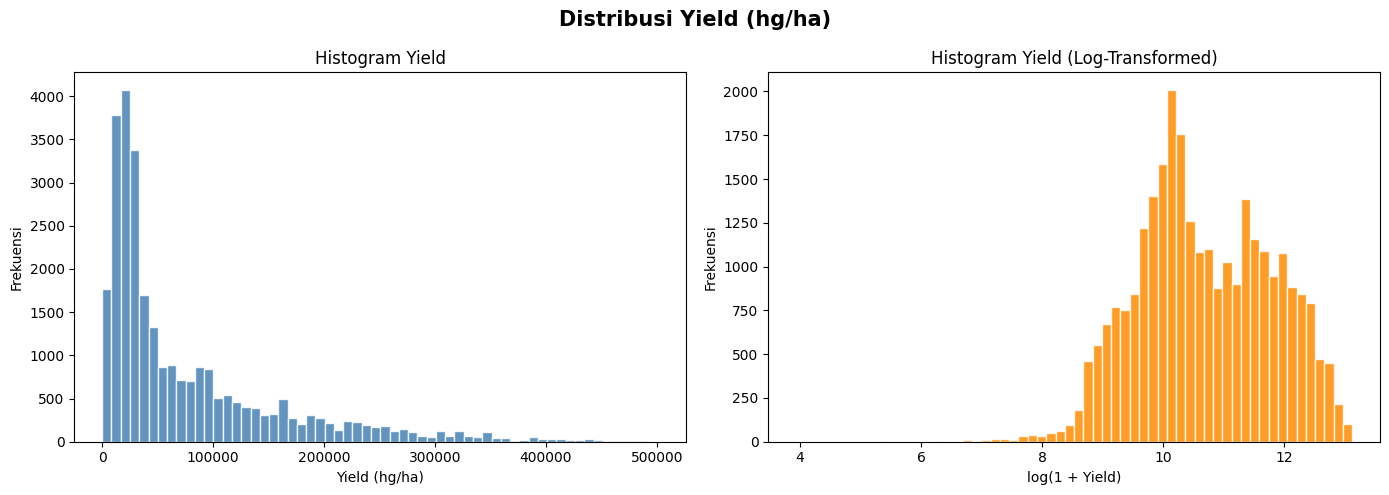

Skewness  : 1.7932  → right-skewed (positif)
Kurtosis  : 3.0661
Median    : 38,295 hg/ha
Mean      : 77,053 hg/ha


In [15]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribusi Yield (hg/ha)', fontsize=15, fontweight='bold')

# Histogram + KDE
axes[0].hist(df['yield_hg_ha'], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Histogram Yield')
axes[0].set_xlabel('Yield (hg/ha)')
axes[0].set_ylabel('Frekuensi')

# Log-transformed distribution (karena right-skewed)
axes[1].hist(np.log1p(df['yield_hg_ha']), bins=60, color='darkorange', edgecolor='white', alpha=0.85)
axes[1].set_title('Histogram Yield (Log-Transformed)')
axes[1].set_xlabel('log(1 + Yield)')
axes[1].set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

skewness = df['yield_hg_ha'].skew()
kurtosis = df['yield_hg_ha'].kurt()
print(f"Skewness  : {skewness:.4f}  → {'right-skewed (positif)' if skewness > 0 else 'left-skewed'}")
print(f"Kurtosis  : {kurtosis:.4f}")
print(f"Median    : {df['yield_hg_ha'].median():,.0f} hg/ha")
print(f"Mean      : {df['yield_hg_ha'].mean():,.0f} hg/ha")


## 4. Analisis Kategorical — Area & Item

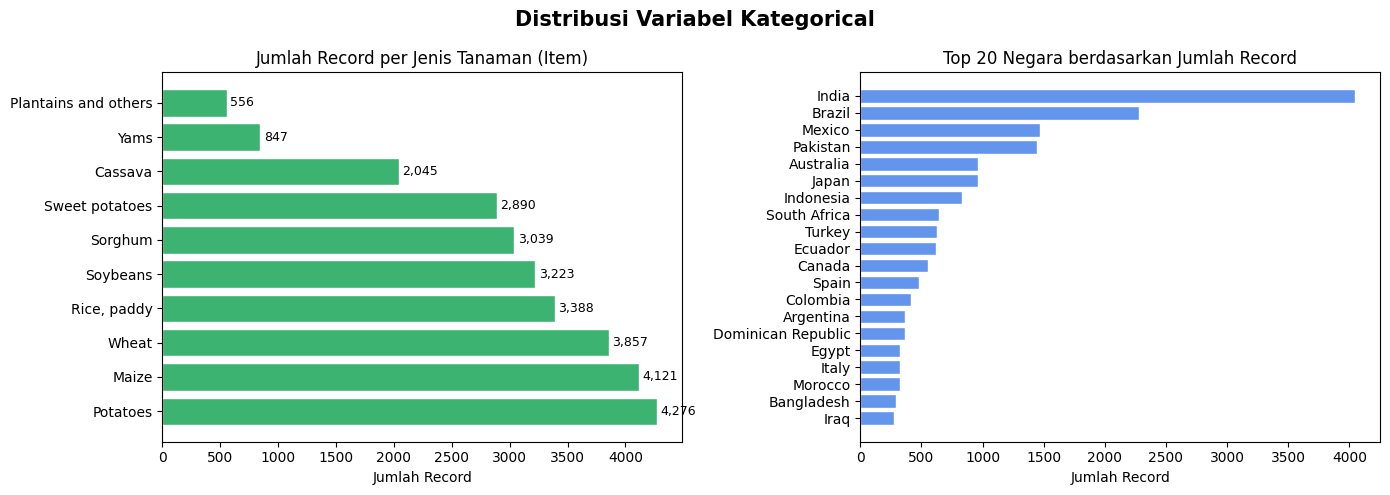


Total negara/wilayah unik : 101
Total jenis tanaman unik  : 10

Jenis tanaman yang ada:
<StringArray>
[               'Maize',             'Potatoes',          'Rice, paddy',
              'Sorghum',             'Soybeans',                'Wheat',
              'Cassava',       'Sweet potatoes', 'Plantains and others',
                 'Yams']
Length: 10, dtype: str


In [25]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribusi Variabel Kategorical', fontsize=15, fontweight='bold')

# Jumlah record per Item (crop type)
item_counts = df['item'].value_counts()
axes[0].barh(item_counts.index, item_counts.values, color='mediumseagreen', edgecolor='white')
axes[0].set_title('Jumlah Record per Jenis Tanaman (Item)')
axes[0].set_xlabel('Jumlah Record')
for i, v in enumerate(item_counts.values):
    axes[0].text(v + 30, i, f'{v:,}', va='center', fontsize=9)

# Top 20 negara berdasarkan jumlah record
top_areas = df['area'].value_counts().head(20)
axes[1].barh(top_areas.index[::-1], top_areas.values[::-1], color='cornflowerblue', edgecolor='white')
axes[1].set_title('Top 20 Negara berdasarkan Jumlah Record')
axes[1].set_xlabel('Jumlah Record')

plt.tight_layout()
plt.show()

print(f"\nTotal negara/wilayah unik : {df['area'].nunique()}")
print(f"Total jenis tanaman unik  : {df['item'].nunique()}")
print(f"\nJenis tanaman yang ada:\n{df['item'].unique()}")


## 5. Yield per Jenis Tanaman (Boxplot)

C:\Users\leona\AppData\Local\Temp\ipykernel_38456\287416254.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='item', y='yield_hg_ha', order=order,
C:\Users\leona\AppData\Local\Temp\ipykernel_38456\287416254.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='item', y='yield_hg_ha', order=order,


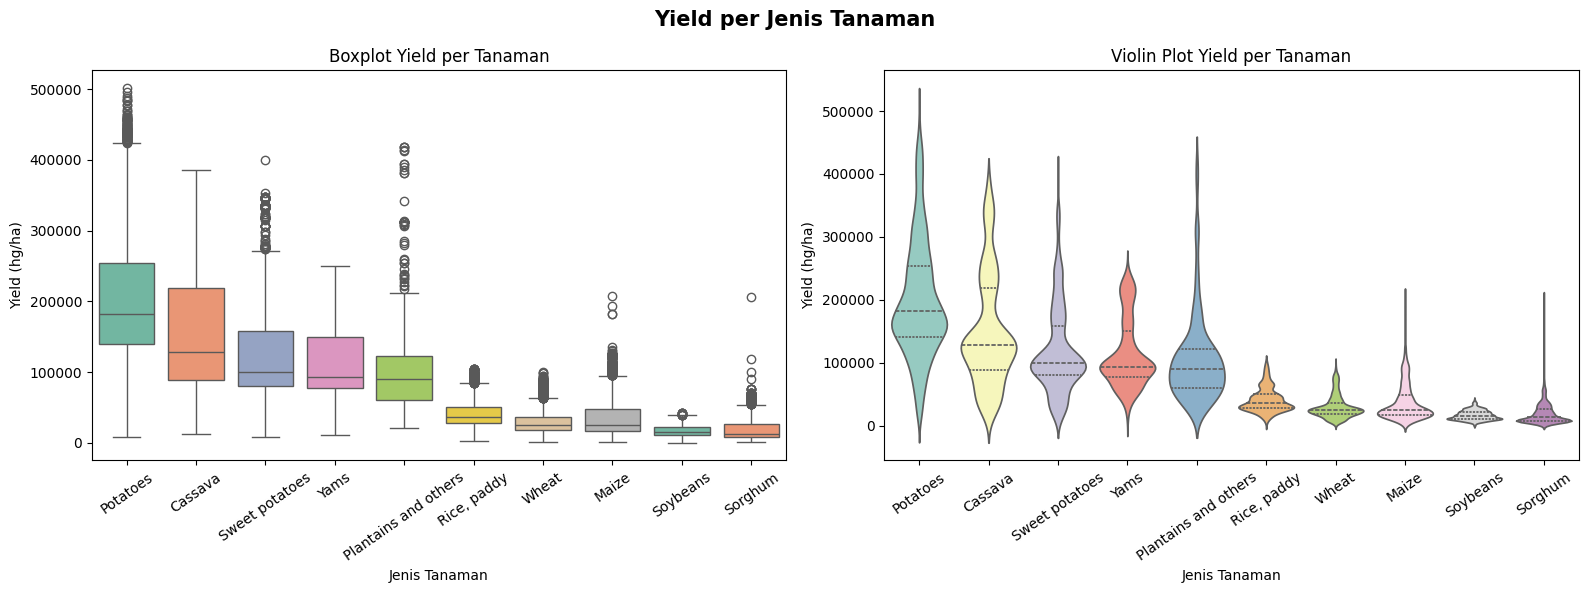


── Statistik Yield per Jenis Tanaman ──


,mean,median,std,min,max
item,,,,,
Potatoes,199801.549579,182271.0,93382.176418,8406,501412
Cassava,150479.466993,128200.0,89738.515066,11778,385818
Sweet potatoes,119057.793772,99940.0,69847.566716,8799,400000
Yams,114140.345927,92593.0,54211.780054,11475,250000
Plantains and others,106041.320144,89860.5,72127.982728,21350,418505
"Rice, paddy",40730.434770,35878.0,19169.699131,2034,103895
Wheat,30116.267825,25497.0,18387.878272,1706,99387
Maize,36310.070614,25401.0,27456.370877,849,207556
Soybeans,16731.092771,15533.0,7603.214681,50,41609


In [24]:

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Yield per Jenis Tanaman', fontsize=15, fontweight='bold')

# Urutkan berdasarkan median yield
order = df.groupby('item')['yield_hg_ha'].median().sort_values(ascending=False).index

# Boxplot
sns.boxplot(data=df, x='item', y='yield_hg_ha', order=order,
            palette='Set2', ax=axes[0])
axes[0].set_title('Boxplot Yield per Tanaman')
axes[0].set_xlabel('Jenis Tanaman')
axes[0].set_ylabel('Yield (hg/ha)')
axes[0].tick_params(axis='x', rotation=35)

# Violinplot untuk melihat distribusi lebih detail
sns.violinplot(data=df, x='item', y='yield_hg_ha', order=order,
               palette='Set3', ax=axes[1], inner='quartile')
axes[1].set_title('Violin Plot Yield per Tanaman')
axes[1].set_xlabel('Jenis Tanaman')
axes[1].set_ylabel('Yield (hg/ha)')
axes[1].tick_params(axis='x', rotation=35)

plt.tight_layout()
plt.show()

# Statistik per tanaman
print("\n── Statistik Yield per Jenis Tanaman ──")
df.groupby('item')['yield_hg_ha'].agg(['mean','median','std','min','max']).sort_values('median', ascending=False)


## 6. Tren Yield Seiring Waktu (1990–2013)

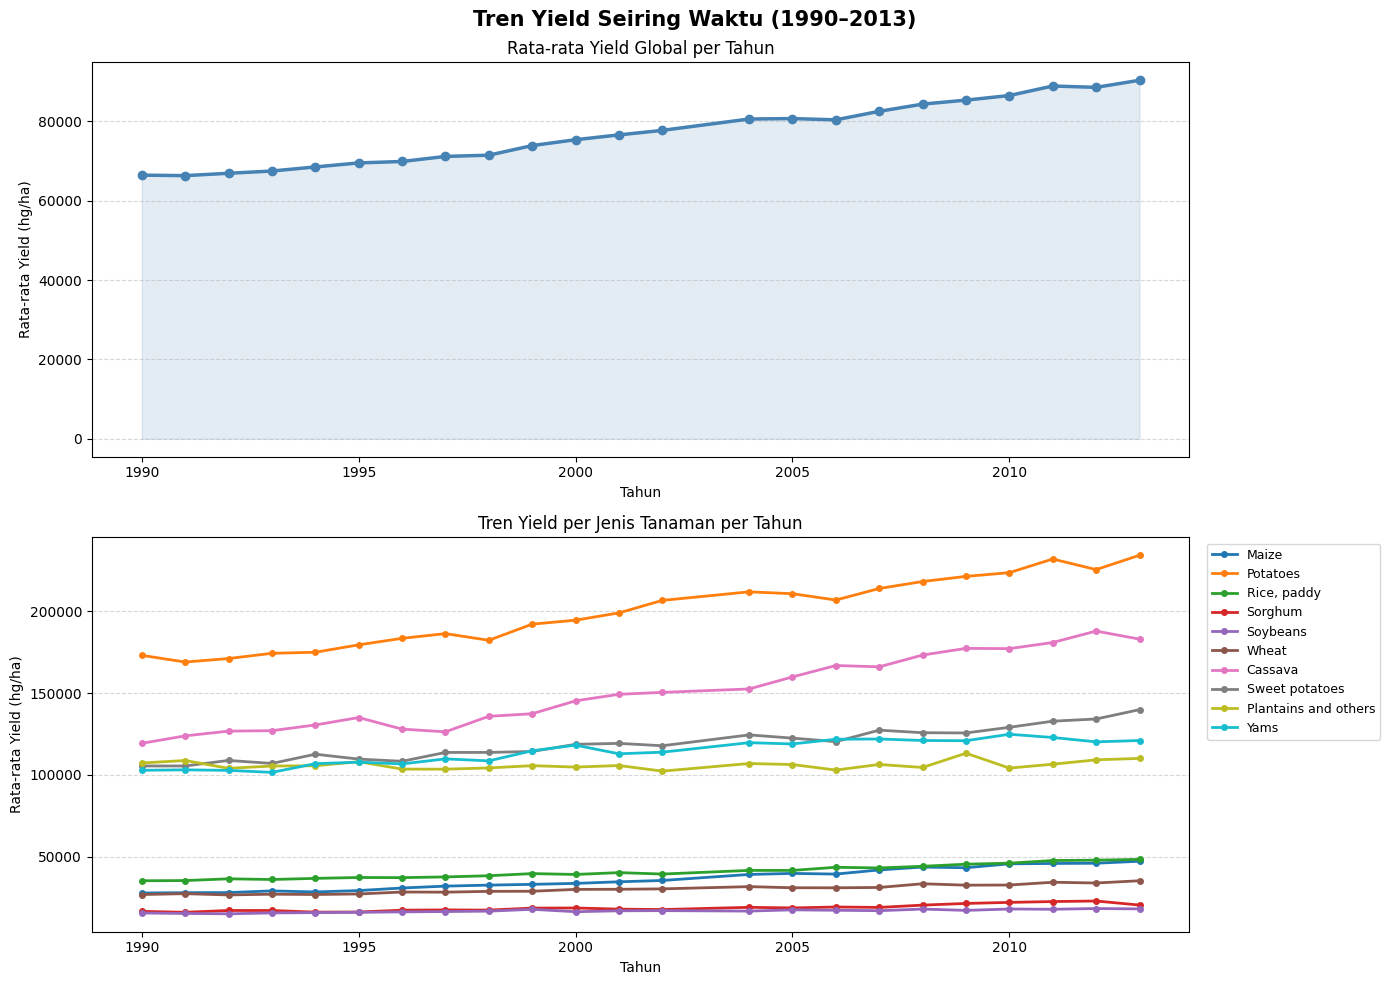

Yield 1990 : 66,447 hg/ha
Yield 2013 : 90,357 hg/ha
Growth     : 36.0% selama 23 tahun


In [16]:

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('Tren Yield Seiring Waktu (1990–2013)', fontsize=15, fontweight='bold')

# Global average yield per year
yearly_avg = df.groupby('year')['yield_hg_ha'].mean().reset_index()
axes[0].plot(yearly_avg['year'], yearly_avg['yield_hg_ha'],
             marker='o', color='steelblue', linewidth=2.5, markersize=6)
axes[0].fill_between(yearly_avg['year'], yearly_avg['yield_hg_ha'],
                     alpha=0.15, color='steelblue')
axes[0].set_title('Rata-rata Yield Global per Tahun')
axes[0].set_xlabel('Tahun')
axes[0].set_ylabel('Rata-rata Yield (hg/ha)')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# Yield per tanaman per tahun
yearly_item = df.groupby(['year', 'item'])['yield_hg_ha'].mean().reset_index()
for item in df['item'].unique():
    subset = yearly_item[yearly_item['item'] == item]
    axes[1].plot(subset['year'], subset['yield_hg_ha'], marker='o',
                 linewidth=2, markersize=4, label=item)

axes[1].set_title('Tren Yield per Jenis Tanaman per Tahun')
axes[1].set_xlabel('Tahun')
axes[1].set_ylabel('Rata-rata Yield (hg/ha)')
axes[1].legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Growth rate overall
start_yield = yearly_avg[yearly_avg['year'] == 1990]['yield_hg_ha'].values[0]
end_yield   = yearly_avg[yearly_avg['year'] == 2013]['yield_hg_ha'].values[0]
print(f"Yield 1990 : {start_yield:,.0f} hg/ha")
print(f"Yield 2013 : {end_yield:,.0f} hg/ha")
print(f"Growth     : {((end_yield - start_yield) / start_yield) * 100:.1f}% selama 23 tahun")


## 7. Yield per Negara — Top & Bottom 15

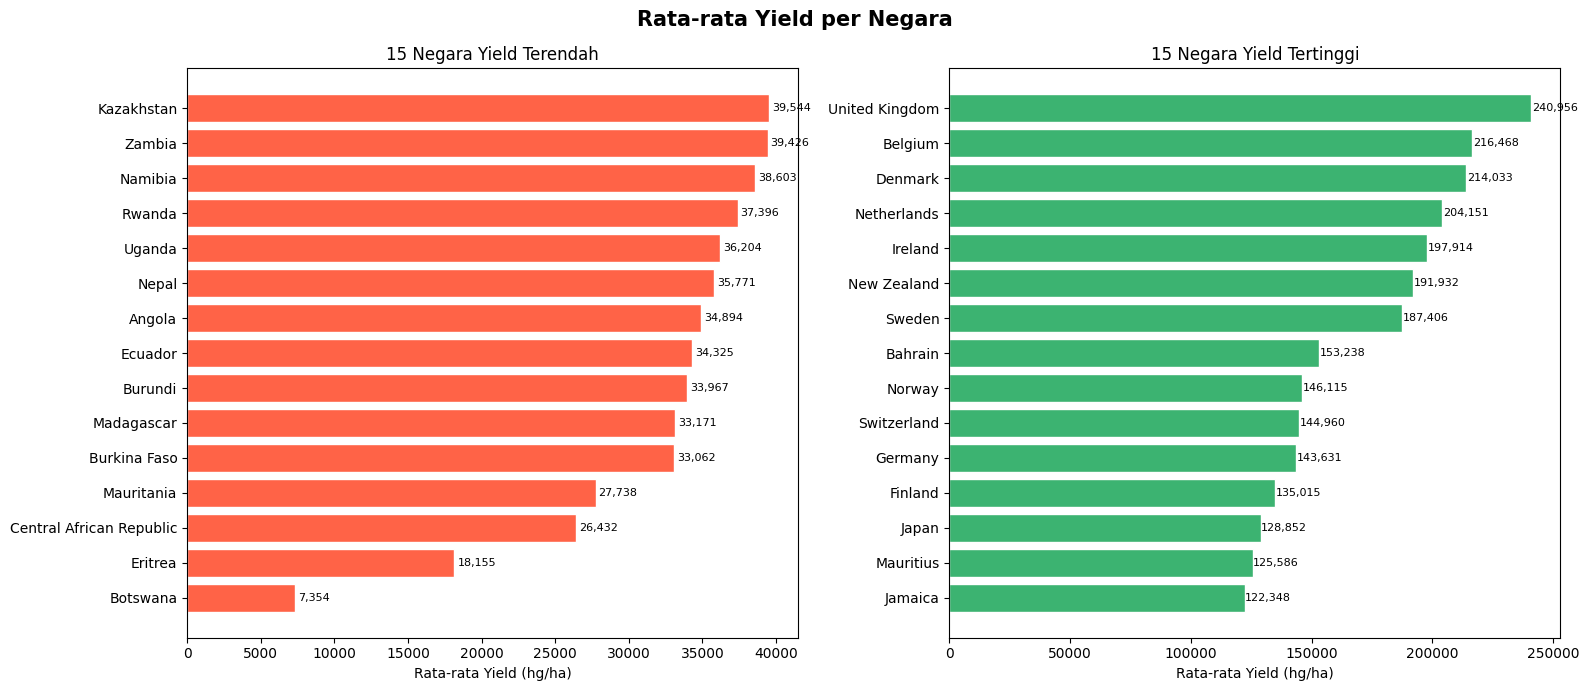


Negara yield tertinggi : United Kingdom (240,956 hg/ha)
Negara yield terendah  : Botswana (7,354 hg/ha)


In [17]:

country_yield = df.groupby('area')['yield_hg_ha'].mean().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Rata-rata Yield per Negara', fontsize=15, fontweight='bold')

# Bottom 15 (yield terendah)
bottom15 = country_yield.head(15)
axes[0].barh(bottom15.index, bottom15.values, color='tomato', edgecolor='white')
axes[0].set_title('15 Negara Yield Terendah')
axes[0].set_xlabel('Rata-rata Yield (hg/ha)')
for i, v in enumerate(bottom15.values):
    axes[0].text(v + 200, i, f'{v:,.0f}', va='center', fontsize=8)

# Top 15 (yield tertinggi)
top15 = country_yield.tail(15)
axes[1].barh(top15.index, top15.values, color='mediumseagreen', edgecolor='white')
axes[1].set_title('15 Negara Yield Tertinggi')
axes[1].set_xlabel('Rata-rata Yield (hg/ha)')
for i, v in enumerate(top15.values):
    axes[1].text(v + 200, i, f'{v:,.0f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

print(f"\nNegara yield tertinggi : {country_yield.idxmax()} ({country_yield.max():,.0f} hg/ha)")
print(f"Negara yield terendah  : {country_yield.idxmin()} ({country_yield.min():,.0f} hg/ha)")


## 8. Analisis Korelasi

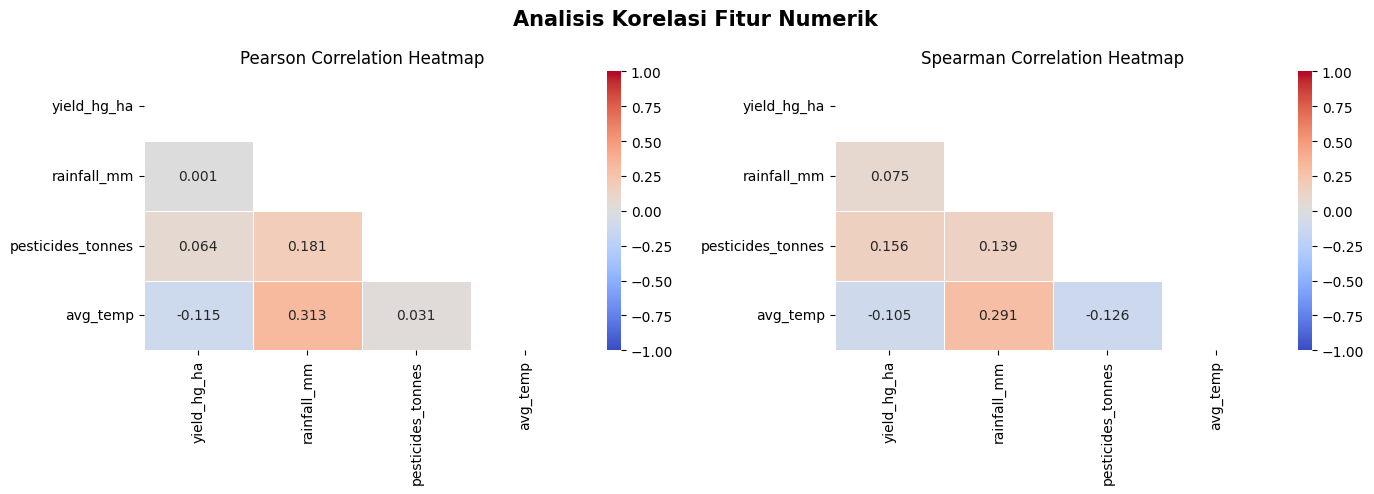


── Korelasi Pearson terhadap yield_hg_ha ──
pesticides_tonnes    0.064085
rainfall_mm          0.000962
avg_temp            -0.114777
Name: yield_hg_ha, dtype: float64

── Korelasi Spearman terhadap yield_hg_ha ──
pesticides_tonnes    0.155835
rainfall_mm          0.074718
avg_temp            -0.104542
Name: yield_hg_ha, dtype: float64


In [18]:

num_cols = ['yield_hg_ha', 'rainfall_mm', 'pesticides_tonnes', 'avg_temp']
corr = df[num_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Analisis Korelasi Fitur Numerik', fontsize=15, fontweight='bold')

# Heatmap Pearson
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            mask=mask, linewidths=0.5, ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title('Pearson Correlation Heatmap')

# Heatmap Spearman (lebih robust untuk non-linear)
spearman_corr = df[num_cols].corr(method='spearman')
mask2 = np.triu(np.ones_like(spearman_corr, dtype=bool))
sns.heatmap(spearman_corr, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            mask=mask2, linewidths=0.5, ax=axes[1], vmin=-1, vmax=1)
axes[1].set_title('Spearman Correlation Heatmap')

plt.tight_layout()
plt.show()

print("\n── Korelasi Pearson terhadap yield_hg_ha ──")
print(corr['yield_hg_ha'].drop('yield_hg_ha').sort_values(ascending=False))
print("\n── Korelasi Spearman terhadap yield_hg_ha ──")
print(spearman_corr['yield_hg_ha'].drop('yield_hg_ha').sort_values(ascending=False))


## 9. Scatter Plot: Fitur vs Yield

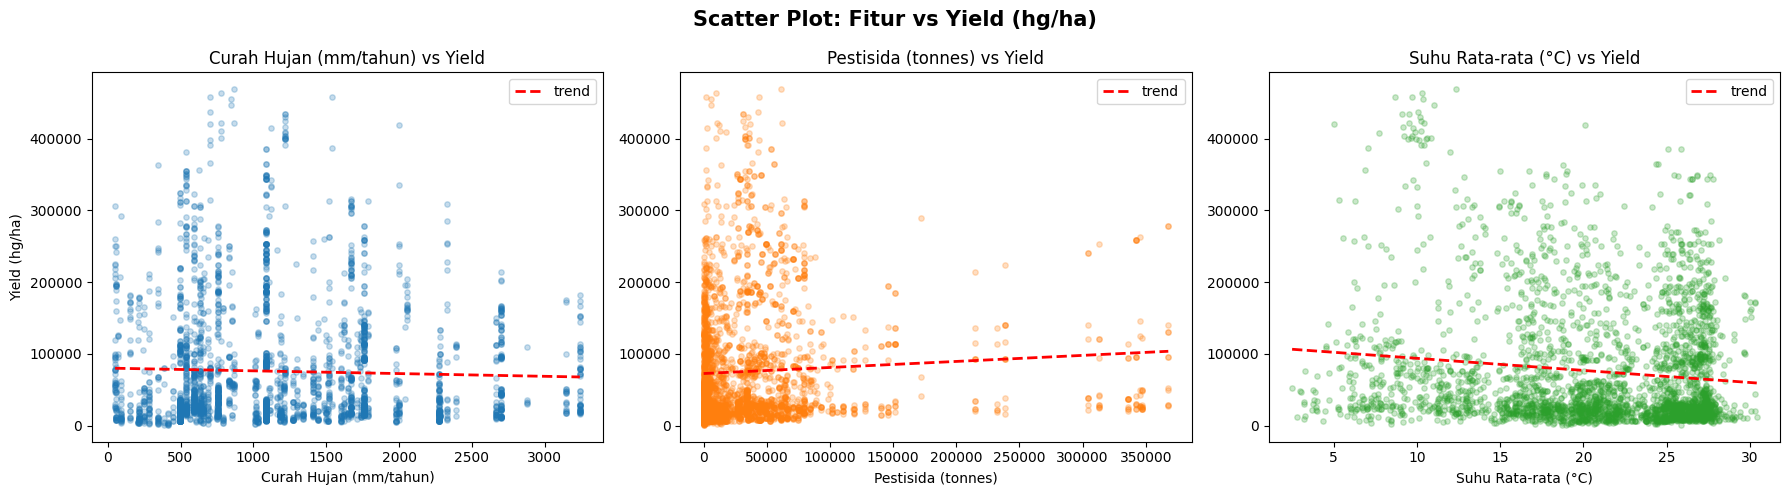

In [19]:

features   = ['rainfall_mm', 'pesticides_tonnes', 'avg_temp']
feat_label = ['Curah Hujan (mm/tahun)', 'Pestisida (tonnes)', 'Suhu Rata-rata (°C)']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Scatter Plot: Fitur vs Yield (hg/ha)', fontsize=15, fontweight='bold')

sample = df.sample(3000, random_state=42)   # subsample agar plot tidak berat

for i, (feat, label) in enumerate(zip(features, feat_label)):
    axes[i].scatter(sample[feat], sample['yield_hg_ha'],
                    alpha=0.25, s=15, color=f'C{i}')
    # Regression line
    z = np.polyfit(sample[feat].dropna(), sample.loc[sample[feat].notna(), 'yield_hg_ha'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(sample[feat].min(), sample[feat].max(), 200)
    axes[i].plot(x_line, p(x_line), 'r--', linewidth=2, label='trend')
    axes[i].set_xlabel(label)
    axes[i].set_ylabel('Yield (hg/ha)' if i == 0 else '')
    axes[i].set_title(f'{label} vs Yield')
    axes[i].legend()

plt.tight_layout()
plt.show()


## 10. Deteksi Outlier (Metode IQR)

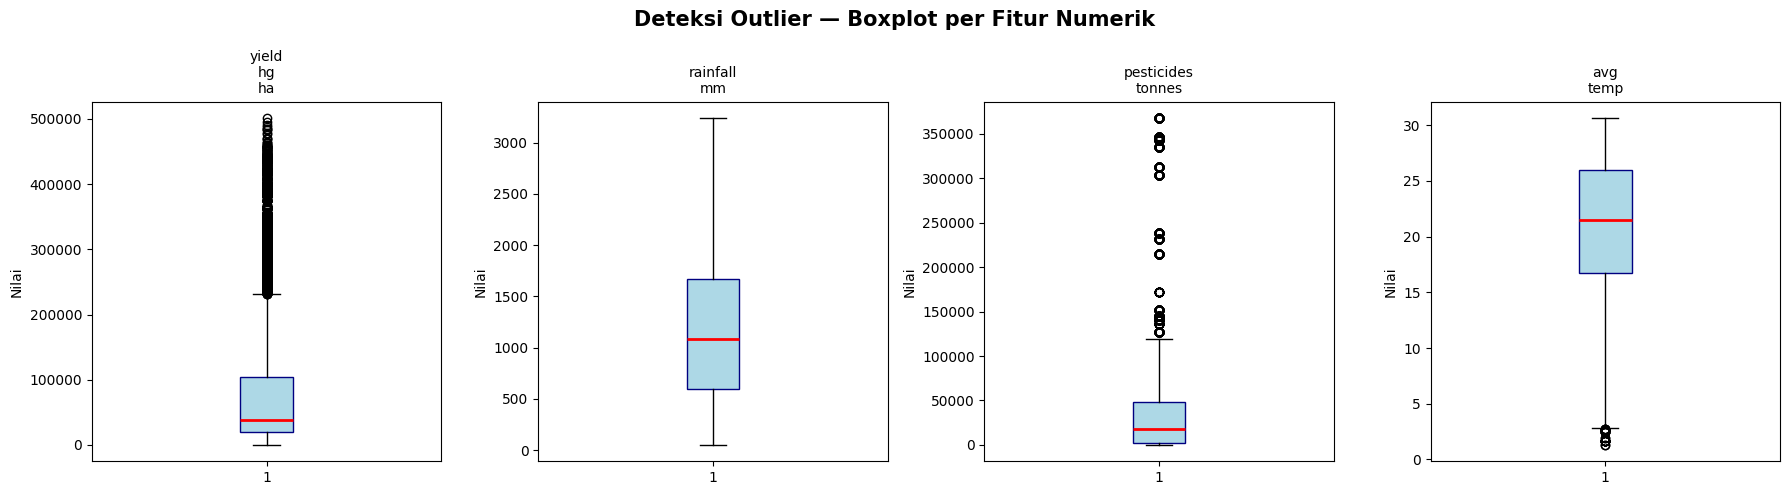


── Ringkasan Outlier per Kolom ──


,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier %
yield_hg_ha,19919.2500,104676.75,84757.5000,-107217.00000,231813.00000,2059.0,7.29
rainfall_mm,593.0000,1668.00,1075.0000,-1019.50000,3280.50000,0.0,0.00
pesticides_tonnes,1702.0000,48687.88,46985.8800,-68776.82000,119166.70000,1418.0,5.02
avg_temp,16.7025,26.00,9.2975,2.75625,39.94625,34.0,0.12


In [27]:

num_cols = ['yield_hg_ha', 'rainfall_mm', 'pesticides_tonnes', 'avg_temp']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Deteksi Outlier — Boxplot per Fitur Numerik', fontsize=15, fontweight='bold')

outlier_summary = {}
for i, col in enumerate(num_cols):
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_summary[col] = {
        'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
        'Lower Bound': lower, 'Upper Bound': upper,
        'Outlier Count': len(outliers),
        'Outlier %': round(len(outliers) / len(df) * 100, 2)
    }
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='lightblue', color='navy'),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col.replace('_', '\n'), fontsize=10)
    axes[i].set_ylabel('Nilai')

plt.tight_layout()
plt.show()

print("\n── Ringkasan Outlier per Kolom ──")
pd.DataFrame(outlier_summary).T


## 11. Pairplot & Distribusi per Fitur

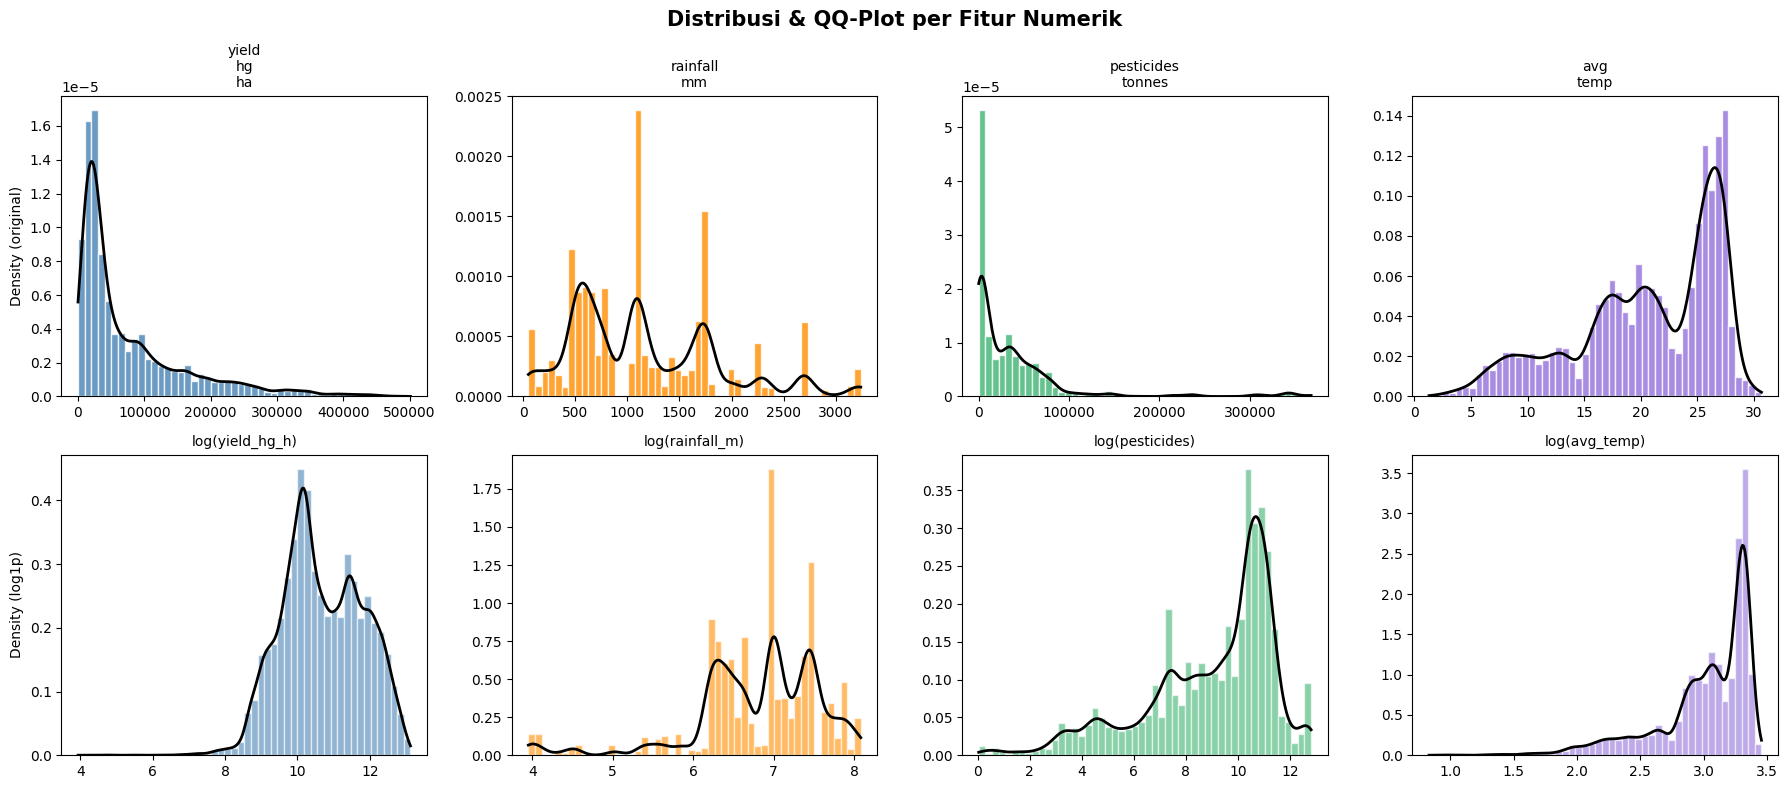

In [ ]:

# Distribusi tiap fitur numerik
num_cols = ['y  ield_hg_ha', 'rainfall_mm', 'pesticides_tonnes', 'avg_temp']
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Distribusi & QQ-Plot per Fitur Numerik', fontsize=15, fontweight='bold')

colors = ['steelblue', 'darkorange', 'mediumseagreen', 'mediumpurple']
for i, col in enumerate(num_cols):
    # Histogram + KDE
    axes[0, i].hist(df[col], bins=50, color=colors[i], edgecolor='white', alpha=0.8, density=True)
    kde_x = np.linspace(df[col].min(), df[col].max(), 300)
    from scipy.stats import gaussian_kde
    kde = gaussian_kde(df[col].dropna())
    axes[0, i].plot(kde_x, kde(kde_x), 'k-', linewidth=2)
    axes[0, i].set_title(col.replace('_', '\n'), fontsize=10)
    axes[0, i].set_xlabel('')

    # Log-transformed
    log_data = np.log1p(df[col])
    axes[1, i].hist(log_data, bins=50, color=colors[i], edgecolor='white', alpha=0.6, density=True)
    kde2 = gaussian_kde(log_data.dropna())
    kde_x2 = np.linspace(log_data.min(), log_data.max(), 300)
    axes[1, i].plot(kde_x2, kde2(kde_x2), 'k-', linewidth=2)
    axes[1, i].set_title(f'log({col[:10]})', fontsize=10)

axes[0, 0].set_ylabel('Density (original)')
axes[1, 0].set_ylabel('Density (log1p)')

plt.tight_layout()
plt.show()


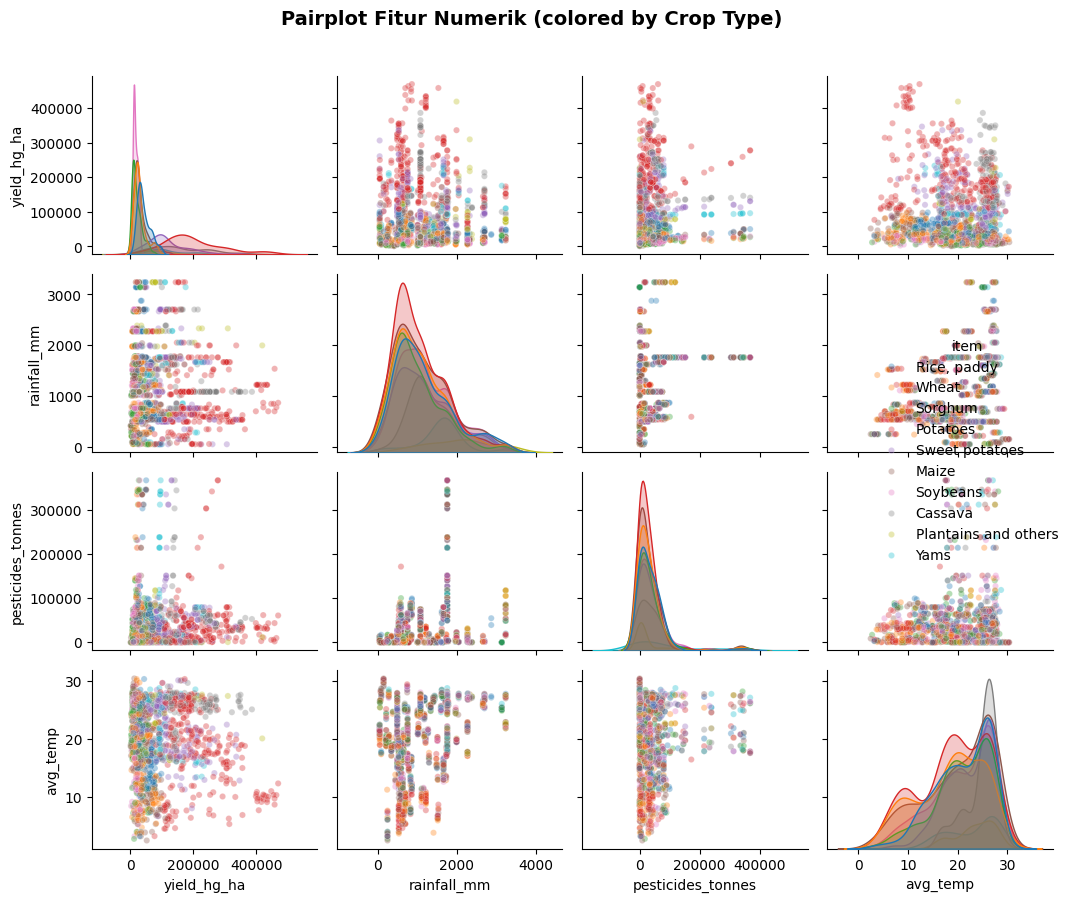

In [28]:

# Pairplot dengan hue per jenis tanaman (subsample agar cepat)
sample_pair = df.sample(2000, random_state=42)
num_cols = ['yield_hg_ha', 'rainfall_mm', 'pesticides_tonnes', 'avg_temp']

pair = sns.pairplot(sample_pair[num_cols + ['item']],
                    hue='item', diag_kind='kde',
                    plot_kws={'alpha': 0.35, 's': 20},
                    height=2.2)
pair.figure.suptitle('Pairplot Fitur Numerik (colored by Crop Type)', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 12. Ringkasan Temuan EDA

In [29]:

print("=" * 65)
print("  RINGKASAN TEMUAN EDA — yield_df.csv")
print("=" * 65)

print(f"""
DATASET
  • {df.shape[0]:,} baris × {df.shape[1]} kolom
  • 101 negara/wilayah, 10 jenis tanaman, tahun 1990–2013
  • Tidak ada missing values

TARGET VARIABLE (yield_hg_ha)
  • Distribusi right-skewed → sebaiknya log-transform sebelum modelling
  • Rentang: {df['yield_hg_ha'].min():,} – {df['yield_hg_ha'].max():,} hg/ha
  • Tanaman dengan yield tertinggi  : {df.groupby('item')['yield_hg_ha'].median().idxmax()}
  • Tanaman dengan yield terendah   : {df.groupby('item')['yield_hg_ha'].median().idxmin()}

TREN WAKTU
  • Yield global meningkat dari 1990 hingga 2013
  • Tren positif konsisten di hampir semua jenis tanaman

KORELASI FITUR
  • pesticides_tonnes memiliki korelasi positif tertinggi dengan yield
  • avg_temp memiliki korelasi negatif moderat terhadap yield
  • rainfall_mm memiliki korelasi lemah terhadap yield

OUTLIER
  • pesticides_tonnes memiliki outlier paling banyak (distribusi sangat right-skewed)
  • yield_hg_ha juga memiliki outlier signifikan — wajar karena variasi tanaman

REKOMENDASI PREPROCESSING
  1. Log-transform pada yield_hg_ha, pesticides_tonnes (skewed)
  2. Label/One-hot encoding pada 'area' dan 'item'
  3. Feature scaling (StandardScaler/MinMaxScaler) sebelum modelling
""")


  RINGKASAN TEMUAN EDA — yield_df.csv

DATASET
  • 28,242 baris × 7 kolom
  • 101 negara/wilayah, 10 jenis tanaman, tahun 1990–2013
  • Tidak ada missing values

TARGET VARIABLE (yield_hg_ha)
  • Distribusi right-skewed → sebaiknya log-transform sebelum modelling
  • Rentang: 50 – 501,412 hg/ha
  • Tanaman dengan yield tertinggi  : Potatoes
  • Tanaman dengan yield terendah   : Sorghum

TREN WAKTU
  • Yield global meningkat dari 1990 hingga 2013
  • Tren positif konsisten di hampir semua jenis tanaman

KORELASI FITUR
  • pesticides_tonnes memiliki korelasi positif tertinggi dengan yield
  • avg_temp memiliki korelasi negatif moderat terhadap yield
  • rainfall_mm memiliki korelasi lemah terhadap yield

OUTLIER
  • pesticides_tonnes memiliki outlier paling banyak (distribusi sangat right-skewed)
  • yield_hg_ha juga memiliki outlier signifikan — wajar karena variasi tanaman

REKOMENDASI PREPROCESSING
  1. Log-transform pada yield_hg_ha, pesticides_tonnes (skewed)
  2. Label/One-hot enco